In [1]:
%reset -f

The necessary libraries for this project are:

In [2]:
import openpyxl
from openpyxl.utils import column_index_from_string
import pandas as pd
import os
from datetime import datetime
import json
import numpy as np
import matplotlib.pyplot as plt
from pyswarm import pso


Import of the `HeatPumpSimulator` class from the `simulation_class.py` file, allowing the simulation of the heat pump's .fmu.

In [ ]:
import importlib
import simulation_class  
importlib.reload(simulation_class)
HeatPumpSimulator = simulation_class.HeatPumpSimulator

## Extraction of the Output Data

Extraction of output data from the `All data` sheet of the Excel file and storing in a DataFrame `df_output`.

- Column K : Water out -> water temperature leaving the heat pump; FMU output
- Column O : Power out -> thermal power of the heat pump (hot side); FMU output
- Column P : Power in -> electrical power of the heat pump; FMU output
- Column Q : COP -> coefficient of performance of the heat pump; FMU output

In [3]:
excel_file_path = './../data/Databrut.xlsx'

workbook = openpyxl.load_workbook(excel_file_path)
sheet = workbook.active

columns_info = {
    "K": "Water_out",
    "O": "Power_out",
    "P": "Power_in",
    "Q": "COP",
    "M": "Defrosts"
}

stored_data = {name: [] for name in columns_info.values()}

for col_letter, col_name in columns_info.items():
    col_index = column_index_from_string(col_letter)
    if col_index <= sheet.max_column:
        for cell in sheet[col_letter]:
            stored_data[col_name].append(cell.value)
    else:
        print(f"Column {col_letter} not found in the sheet.")

workbook.close()

df_output = pd.DataFrame(stored_data)
df_output = df_output.drop([0, 1, 2, 3])  

for column in ["Water_out", "Power_out", "Power_in", "COP"]:
    df_output[column] = pd.to_numeric(df_output[column], errors='coerce')

df_output.dropna(subset=["Water_out", "Power_out", "Power_in", "COP"], inplace=True)
df_output['Water_out'] = df_output['Water_out'] + 273.15
df_output = df_output.rename(columns={'Water_out': 'y_T_out', 'Power_out': 'y_heatPower', 'Power_in': 'y_elecPower', 'COP': 'y_COP'})

df_output.head()


,y_T_out,y_heatPower,y_elecPower,y_COP,Defrosts
4,308.248729,8628.775284,2022.298343,4.279641,no
5,308.320939,8589.444308,2044.149171,4.214619,no
6,308.179724,7641.797307,1748.723757,4.383122,no
7,308.268453,6873.783742,1477.259669,4.667061,no
8,308.200442,6035.440249,1248.497238,4.848746,no


In [4]:
Outputpath = './../data/df_output.csv'
df_output.to_csv(Outputpath, index=False)

## Extraction of the Input Data

Extraction of the input data from the `All data` sheet of the Excel file and storing in a DataFrame `df_input`.

- Column I : Frequency -> compressor frequency; FMU input
- Column J : Water in -> water temperature at the heat pump inlet; FMU input
- Column L : Flow -> water flow; FMU input
- Column M : Defrosts -> indicates if defrosting took place during the test

In [5]:
excel_file_path = './../data/Databrut.xlsx'

workbook = openpyxl.load_workbook(excel_file_path)
sheet = workbook.active

columns_info = {
    "I": "Frequency",
    "J": "Water_in",
    "L": "Flow",
    "M": "Defrosts"  
}

stored_data = {name: [] for name in columns_info.values()}

for col_letter, col_name in columns_info.items():
    col_index = column_index_from_string(col_letter)
    if col_index <= sheet.max_column:
        for row in sheet.iter_rows(min_row=2, max_col=col_index, min_col=col_index, values_only=True):  
            stored_data[col_name].extend(row)
    else:
        print(f"Column {col_letter} not found in the sheet.")

workbook.close()

df_input = pd.DataFrame(stored_data)

for column in ["Frequency", "Water_in", "Flow"]:
    df_input[column] = pd.to_numeric(df_input[column], errors='coerce')

df_input.dropna(subset=["Frequency", "Water_in", "Flow"], inplace=True)


# Création de la colonne 'T_air' avec les valeurs correctes
NbA12W35,NbA12W45 = 9,9
NbA7W35,NbA7W45,NbA7W55 = 13,12,4
NbA2W35,NbA2W45,NbA2W55  = 5,5,5
NbAmoins7W35,NbAmoins7W45,NbAmoins7W55 = 5,5,5

NbA12 = NbA12W35 + NbA12W45
NbA7 = NbA7W35 + NbA7W45 + NbA7W55
NbA2 = NbA2W35 + NbA2W45 + NbA2W55
NbAmoins7 = NbAmoins7W35 + NbAmoins7W45 + NbAmoins7W55

values = [12]*NbA12 + [7]*NbA7 + [2]*NbA2 + [-7]*NbAmoins7

if len(values) == len(df_input):
    df_input['T_air'] = values
else:
    print("Erreur : La longueur des valeurs de 'T_air' ne correspond pas au DataFrame.")

columns_order = ["Frequency", "Water_in", "Flow", "T_air", "Defrosts"] 
df_input = df_input[columns_order] 


In [6]:
# Conversion de la température de l'eau de °C à K
df_input['Water_in'] = df_input['Water_in'] + 273.15

# Conversion du débit d'eau de m³/h à m³/s
df_input['Flow'] = df_input['Flow'] / 3600

# Conversion de la température de l'air de °C à K
df_input['T_air'] = df_input['T_air'] + 273.15

df_input.head()

,Frequency,Water_in,Flow,T_air,Defrosts
3,105.6,303.262818,0.000415,285.15,no
4,98.4,303.289006,0.000409,285.15,no
5,88.2,303.231215,0.000370,285.15,no
6,78.0,303.359724,0.000336,285.15,no
7,68.4,303.246077,0.000292,285.15,no


In [7]:
Inputpath = './../data/df_input.csv'
df_input.to_csv(Inputpath, index=False)


## Fisrt Simulation

Firstly, we ignore the tests where "Defrosts" = yes (column M)

In [8]:
df_input_no_defrost = df_input[df_input['Defrosts'] == 'no']
df_output_no_defrost = df_output[df_output['Defrosts'] == 'no']


In this notebook, we are importing the Python class `HeatPumpSimulator` that utilizes FMpy to simulate FMU. This class is responsible for performing the simulation of the heat pump system. Below are the defined inputs and outputs for the simulation.


#### FMU Inputs

- **u_compressorFrequency:** Compressor Frequency *Unit:* Hz

- **u_VFlow:** Water Flow *Unit:* m³/s

- **u_T_water:** Water Temperature Entering the Heat Pump *Unit:* K

- **u_T_air:** Air Temperature at the Heat Pump Inlet *Unit:* K

#### FMU Outputs

- **y_T_out:** Water Temperature Leaving the Heat Pump *Unit:* K

- **y_heatPower:** Thermal Power of the Heat Pump (Hot Side) *Unit:* W

- **y_elecPower:** Electrical Power of the Heat Pump *Unit:* W

- **y_COP:** Coefficient of Performance of the Heat Pump *Unit:* []


In [9]:
simulator = HeatPumpSimulator('../FMU/HPFMU_20_Linux.fmu')

last_rows = []

for index, row in df_input_no_defrost.head(10).iterrows():
    start_values = {
        'u_compressorFrequency': row['Frequency'],
        'u_VFlow': row['Flow'],
        'u_T_watrer_in': row['Water_in'],
        'u_T_air': row['T_air'],
        # Valeurs fixes des paramètres pour l'instant
        'x_areaLeakage': 5e-7,
        'x_areaSuctionValve': 5e-4,
        'x_areaDischargeValve': 5e-5,
        'x_relativeDeadSpace': 0.05,
        'x_driveEfficiency': 0.9
    }

    simulation_result = simulator.simulate(start_values)
    df_simulation_result = pd.DataFrame(simulation_result)
    last_row = df_simulation_result.iloc[-1]
    last_rows.append(last_row)


In [10]:
df_final_results = pd.DataFrame(last_rows)
df_final_results = df_final_results.drop(columns=['time'])
df_final_results = df_final_results.reset_index(drop=True)

df_final_results.head()


,y_T_out,y_heatPower,y_elecPower,y_COP
0,308.585764,9181.373552,2427.614040,3.782057
1,308.320366,8559.788081,2223.600652,3.849517
2,308.191957,7635.408713,1945.937162,3.923769
3,308.135888,6669.292055,1680.123506,3.969525
4,307.972277,5738.200241,1435.660306,3.996907


## Overview of the process

<img src="calibration_process.jpg" alt="Image Description" width="800" height="400"/>


## 1 - LINE BY LINE CALIBRATION (defrost = no) 

We separate the data into two groups: a first group on which we will carry out the calibration and a second group on which we will carry out the validation.

We take a size of 90% for the first group and 10% for the second group.

In [11]:
size_train = 0.9

In [12]:
df_input_no_defrost_cal = df_input_no_defrost.sample(frac=size_train, random_state=0)
df_input_no_defrost_test = df_input_no_defrost.drop(df_input_no_defrost_cal.index)

df_output_no_defrost_cal = df_output_no_defrost.sample(frac=size_train, random_state=0)
df_output_no_defrost_test = df_output_no_defrost.drop(df_output_no_defrost_cal.index)

We create a fonction that allows us to save all the results of the calibration.

In [13]:
def save_results(results, filename_prefix="pso_results", size_train=0.9):
    """
    Save the results of the PSO algorithm in a JSON file.

    Parameters
    ----------
    results : dict
        Dictionary containing the results of the PSO algorithm.
    filename_prefix : str, optional
        Prefix of the filename.
    size_train : float, optional
        Percentage of the dataset used for training.
    """
    try:
        current_script_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        current_script_dir = os.getcwd()

    results_dir = os.path.join(current_script_dir, "results_" + str(int(size_train * 100)))

    if not os.path.exists(results_dir):
        os.makedirs(results_dir)

    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")  
    filename = f"{filename_prefix}_{timestamp}.json"
    filepath = os.path.join(results_dir, filename)

    
    for key, res in results.items():
        for subkey, value in res.items():
            if isinstance(value, np.ndarray):
                res[subkey] = value.tolist()

    
    with open(filepath, "w") as f:
        json.dump(results, f, indent=4)

    print(f"Results saved in {filepath}")

### A method for calibrating

We define our objective function which is the sum of the square of the differences between the simulated values and the measured values. We use `simulate_with_timeout` to simulate the FMU. This function allows us to simulate the FMU with a timeout.

In [19]:
def objective_function(params, line_index=0):
    """
    Objective function for the PSO algorithm.

    Parameters
    ----------
    params : list
        List of parameters to evaluate.
    line_index : int, optional
        Index of the line to evaluate in the dataset.

    Returns
    -------
    float
        Error between the simulation and the real data.
    """
    print(f"Évaluation des paramètres pour la ligne {line_index + 1}")
    input_row = df_input_no_defrost_cal.iloc[line_index]
    output_row = df_output_no_defrost_cal.iloc[line_index]

    start_values = {
        'u_compressorFrequency': input_row['Frequency'],
        'u_VFlow': input_row['Flow'],
        'u_T_watrer_in': input_row['Water_in'],
        'u_T_air': input_row['T_air'],
        'x_areaLeakage': params[0],
        'x_areaSuctionValve': params[1],
        'x_areaDischargeValve': params[2],
        'x_relativeDeadSpace': params[3],
        'x_driveEfficiency': params[4]
    }

    simulation_result = simulator.simulate_with_timeout(
        start_values, timeout=10)
    if not simulation_result:
        print("La simulation a échoué ou a été interrompue.")
        return float('inf')

    last_row = pd.DataFrame(simulation_result).iloc[-1]
    error = np.sum((last_row[['y_T_out', 'y_heatPower', 'y_elecPower', 'y_COP']] -
                    [output_row['y_T_out'], output_row['y_heatPower'], output_row['y_elecPower'], output_row['y_COP']])**2)
    print(f"Erreur : {error}")

    return error

The bounds of the parameters :

In [15]:
lb = [1e-8, 2e-6, 1e-7, 0.001, 0.85]
ub = [1e-6, 1e-3, 1e-4, 0.1, 0.98]

Calibration function that use `pso` from the `pyswarm` library to perform the calibration using the particle swarm optimization algorithm.

In [16]:
def line_calibration(df_input_no_defrost_cal, swarm_size, max_iter):
    """
    Calibration of the parameters for each line of the dataset.

    Parameters
    ----------
    df_input_no_defrost_cal : pandas.DataFrame
        Input dataset for the calibration.
    swarm_size : int
        Number of particles in the swarm.
    max_iter : int
        Maximum number of iterations.

    Returns
    -------
    dict
        Dictionary containing the results of the PSO algorithm.
    """
    
    pso_results = {}
    
    for line_index in range(len(df_input_no_defrost_cal)):
        print(f"Calibration pour la ligne {line_index + 1}")

        xopt, fopt = pso(lambda params: objective_function(
            params, line_index), lb, ub, swarmsize=swarm_size, maxiter=max_iter)

        print(f"Meilleure solution pour la ligne {line_index + 1}:", xopt)
        print(f"Erreur minimale pour la ligne {line_index + 1}:", fopt)

        pso_results[line_index] = {
            "xopt": xopt,
            "fopt": fopt
        }

        save_results(pso_results, filename_prefix="pso_results_defrost_no")

    return pso_results


<div class="alert alert-block alert-warning">
<b>Warning:</b> The calibration can take a long time (several hours) depending on the number of iterations and the number of particles. (swarm_size = 9 and  max_iter = 18 -> 10 hours)

In [17]:
# swarm_size = 9
# max_iter = 18
# pso_results = line_calibration(df_input_no_defrost_cal, swarm_size, max_iter)
# print(pso_results)

## 2 - POST CALIBRATION ANALYSIS : Selection of the best parameters obtained during the calibration

We export the `json` results file we want to use for the validation.

In [4]:
with open('results_90/pso_results_defrost_no_2024-01-28_00-26-46.json', 'r') as f:
    optimized_params = json.load(f)


We only select the parameters sets that have an error under $500$.

In [5]:
filtered_params = {k: v for k, v in optimized_params.items()
                   if v['fopt'] < 500}

In [6]:
print(f"{len(filtered_params)} sets on {len(optimized_params)} have an error below 500.")

18 sets on 39 have an error below 500.


In [16]:
df_input_no_defrost_test.reset_index(drop=True, inplace=True)
df_output_no_defrost_test.reset_index(drop=True, inplace=True)


Here we can see the test data we are going to use for the validation.

In [17]:
print(df_input_no_defrost_test)

   Frequency    Water_in      Flow   T_air Defrosts
0      105.6  303.262818  0.000415  285.15       no
1       78.0  303.359724  0.000336  285.15       no
2       48.0  313.616983  0.000304  275.15       no
3       48.0  321.766341  0.000189  275.15       no


In [18]:
print(df_output_no_defrost_test)

      y_T_out  y_heatPower  y_elecPower     y_COP Defrosts
0  308.248729  8628.775284  2022.298343  4.279641       no
1  308.268453  6873.783742  1477.259669  4.667061       no
2  316.088804  3132.961400  1063.892550  2.944810       no
3  325.354283  2828.420388  1260.977890  2.243037       no


This is the function we use to calculate the error between the simulated values and the measured values, with the `weights` dictionary we can select witch performance indicators we want to concentrate on.

In [ ]:
def calculate_error(simulated_results, expected_results, verbose=False):
    """
    Calculate the error between the simulated results and the expected results.

    Parameters
    ----------
    simulated_results : dict
        Dictionary containing the simulated results.
    expected_results : pandas.DataFrame
        DataFrame containing the expected results.
    verbose : bool, optional
        If True, print the individual errors.

    Returns
    -------
    float
        Total error.
    dict
        Dictionary containing the individual errors.
    """
    errors = {}
    
    expected_results_dict = expected_results.drop('Defrosts').to_dict()

    last_row = {var: values[-1] for var, values in simulated_results.items() if var in expected_results_dict}

    # Weights to prioritize some variables over others
    weights = {
        'y_T_out': 1.0,  
        'y_heatPower': 3.0,  
        'y_elecPower': 3.0, 
        'y_COP': 2.0  
    }

    if verbose:
        print("Individual errors:")  

    for col, expected_value in expected_results_dict.items():
        final_simulated_value = last_row.get(col, np.nan)

        # Calculate the weighted error
        error = weights[col] * (abs(final_simulated_value - expected_value)) if not np.isnan(final_simulated_value) else np.nan
        errors[col] = error
        if verbose:
            print(f"Difference for {col}: {abs(final_simulated_value - expected_value)}")  

    total_error = np.nanmean(list(errors.values()))
    return total_error, errors


This cell will returns the key of the best parameters set in the results file we loaded. (`best_params_key`)

In [24]:
total_errors = {}

for key, params in filtered_params.items():
    errors_list = []
    for index, input_row in df_input_no_defrost_test.iterrows():
        start_values = {
            'u_compressorFrequency': input_row['Frequency'],
            'u_VFlow': input_row['Flow'],
            'u_T_watrer_in': input_row['Water_in'],
            'u_T_air': input_row['T_air'],
            'x_areaLeakage': params['xopt'][0],
            'x_areaSuctionValve': params['xopt'][1],
            'x_areaDischargeValve': params['xopt'][2],
            'x_relativeDeadSpace': params['xopt'][3],
            'x_driveEfficiency': params['xopt'][4]
        }

        simulation_results = simulator.simulate_with_timeout(start_values)
        total_error, errors = calculate_error(
            simulation_results, df_output_no_defrost_test.iloc[index])
        if not np.isnan(total_error):  
            errors_list.append({'total_error': total_error, **errors})

    if errors_list:  
        avg_errors = pd.DataFrame(errors_list).mean().to_dict()
        total_errors[key] = {'total_error': avg_errors.pop(
            'total_error'), 'errors': avg_errors}

if total_errors:
    best_params_key = min(
        total_errors, key=lambda k: total_errors[k]['total_error'])
    best_params = filtered_params[best_params_key]
    best_error = total_errors[best_params_key]
    print(
        f"Best parameters set: {best_params_key} with total error: {best_error['total_error']}")
else:
    print("No successful simulations were completed.")

[WARNING] Warning: The following was detected at time: 438.3707457616714
[WARNING] TSMedia-Error(HPFMU.valve.vleFluidB.vleFluidPointer, HelmholtzModel::Trho(p,h), mediumPointerID=3399): Could not find T and rho. p=1.02733e+06 h=-815324

[WARNING] The stack of functions is:
[WARNING] density_phxi_Unique9
[WARNING] squareRoot_mdot_dp_mdotSmooth_VLEFluid_Unique8(
valve.vleFluidA.p, 
valve.vleFluidB.p, 
valve.vleFluidA.h, 
valve.vleFluidB.h, 
valve.vleFluidA.xi, 
valve.vleFluidB.xi, 
valve.vleFluidA.vleFluidPointer, 
valve.vleFluidB.vleFluidPointer, 
2500.0, 
2)
[WARNING] 
[WARNING] Warning: The following was detected at time: 438.3707457616714
[WARNING] TSMedia-Error(HPFMU.Evaporator.vleFluidCell[1].vleFluid.vleFluidPointer, HelmholtzModel::Trho(p,h), mediumPointerID=3421): Could not find T and rho. p=1.02733e+06 h=-815324

[WARNING] The stack of functions is:
[WARNING] TSMedia.Internals.VLEFluidObjectFunctions.additionalProperties_phxi
[WARNING] TSMedia.Internals.VLEFluidObjectFunctions.

/tmp/ipykernel_3238720/3593570036.py:26: RuntimeWarning: Mean of empty slice
  total_error = np.nanmean(list(errors.values()))


Simulation timeout reached for parameters: {'u_compressorFrequency': 48.0, 'u_VFlow': 0.00030369915625482017, 'u_T_watrer_in': 313.61698275566863, 'u_T_air': 275.15, 'x_areaLeakage': 5.800507345780862e-07, 'x_areaSuctionValve': 0.000892236711227286, 'x_areaDischargeValve': 2.5502315455285626e-05, 'x_relativeDeadSpace': 0.052271623803225274, 'x_driveEfficiency': 0.9798991570069411}
Simulation timeout reached for parameters: {'u_compressorFrequency': 48.0, 'u_VFlow': 0.00018888792075163376, 'u_T_watrer_in': 321.7663413093307, 'u_T_air': 275.15, 'x_areaLeakage': 5.800507345780862e-07, 'x_areaSuctionValve': 0.000892236711227286, 'x_areaDischargeValve': 2.5502315455285626e-05, 'x_relativeDeadSpace': 0.052271623803225274, 'x_driveEfficiency': 0.9798991570069411}
Best parameters set: 24 with total error: 378.6848857137147


In [68]:
print("Best parameters:")
print(optimized_params[best_params_key]['xopt'])

Best parameters:
[1e-08, 5.724439745087251e-05, 4.353043641598575e-05, 0.09933469072929339, 0.8963402568638703]


## 3 - CROSS VALIDATION

In [36]:
expected_results = {
    'y_T_out': [],
    'y_heatPower': [],
    'y_elecPower': [],
    'y_COP': []
}

simulation_results = {
    'y_T_out': [],
    'y_heatPower': [],
    'y_elecPower': [],
    'y_COP': []
}

errors_list = []
for index, (input_row, output_row) in enumerate(zip(df_input_no_defrost_test.iterrows(), df_output_no_defrost_test.iterrows())):
    _, input_row = input_row  
    _, output_row = output_row  

    print(f"Testing input row index: {index}")
    start_values = {
        'u_compressorFrequency': input_row['Frequency'],
        'u_VFlow': input_row['Flow'],
        'u_T_watrer_in': input_row['Water_in'],
        'u_T_air': input_row['T_air'],
        'x_areaLeakage': optimized_params[best_params_key]['xopt'][0],
        'x_areaSuctionValve': optimized_params[best_params_key]['xopt'][1],
        'x_areaDischargeValve': optimized_params[best_params_key]['xopt'][2],
        'x_relativeDeadSpace': optimized_params[best_params_key]['xopt'][3],
        'x_driveEfficiency': optimized_params[best_params_key]['xopt'][4]
    }

    simulation_result = simulator.simulate_with_timeout(start_values)
    last_row = pd.DataFrame(simulation_result).iloc[-1]
    
    for key in simulation_results.keys():
        simulation_results[key].append(last_row[key])
    
    for key in expected_results.keys():
        expected_results[key].append(output_row[key])

    total_error, errors = calculate_error(simulation_result, output_row, verbose=False)
    if not np.isnan(total_error):  
        errors_list.append({'total_error': total_error, **errors})

Testing input row index: 0
Testing input row index: 1
Testing input row index: 2
Testing input row index: 3


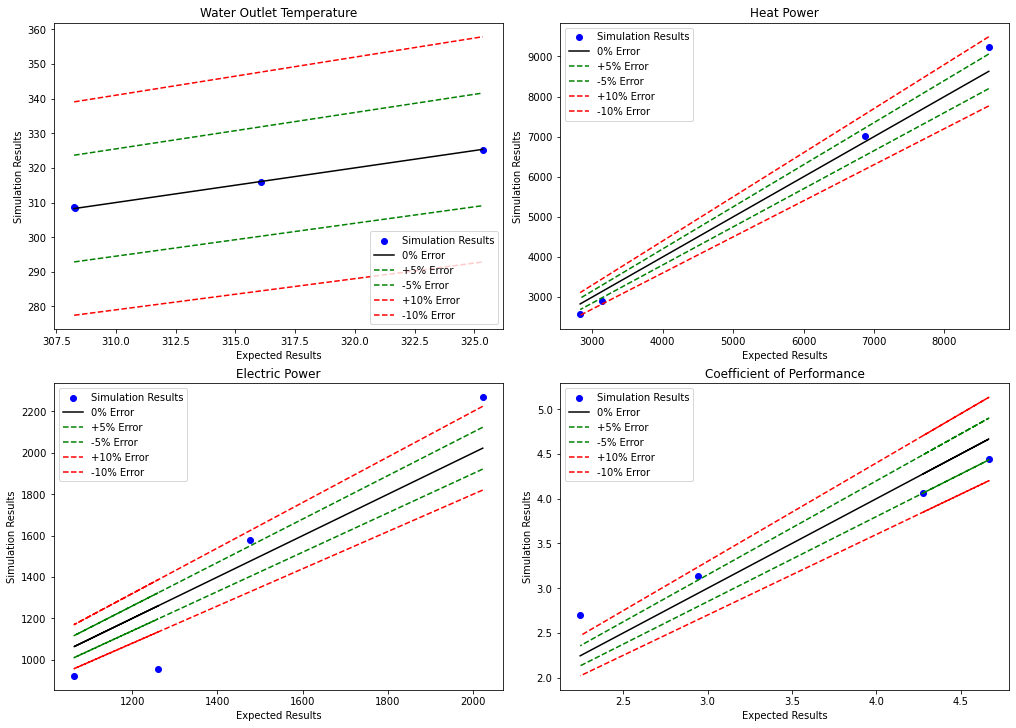

In [37]:
percentage_errors = {key: np.array(simulation_results[key]) / np.array(expected_results[key]) - 1
                     for key in expected_results.keys()}

def plot_errors_with_lines(expected, simulated, ax, title):
    """
    Plot the errors between the simulated results and the expected results.

    Parameters
    ----------
    expected : list
        List of expected results.
    simulated : list
        List of simulated results.
    ax : matplotlib.axes.Axes
        Axes to plot the results.
    title : str
        Title of the plot.
    """
    ax.scatter(expected, simulated, color='blue', label='Simulation Results')
    ax.plot(expected, expected, 'k-', label='0% Error')
    ax.plot(expected, np.array(expected) * 1.05, 'g--', label='+5% Error')
    ax.plot(expected, np.array(expected) * 0.95, 'g--', label='-5% Error')
    ax.plot(expected, np.array(expected) * 1.10, 'r--', label='+10% Error')
    ax.plot(expected, np.array(expected) * 0.90, 'r--', label='-10% Error')
    ax.set_xlabel('Expected Results')
    ax.set_ylabel('Simulation Results')
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

plot_errors_with_lines(expected_results['y_T_out'], simulation_results['y_T_out'], axes[0, 0], 'Water Outlet Temperature')
plot_errors_with_lines(expected_results['y_heatPower'], simulation_results['y_heatPower'], axes[0, 1], 'Heat Power')
plot_errors_with_lines(expected_results['y_elecPower'], simulation_results['y_elecPower'], axes[1, 0], 'Electric Power')
plot_errors_with_lines(expected_results['y_COP'], simulation_results['y_COP'], axes[1, 1], 'Coefficient of Performance')

plt.show()
